# Step 1: Food generation (habit-biased weighted sampling)

This notebook cell set implements Step 1 from `plan.md`:
- Load food options from `foods.json`
- Generate per-user baseline food preference weights (slight randomization)
- Generate semi-regular meal timing windows:
  - Breakfast: 7-10am
  - Lunch: 11am-2pm
  - Dinner: 6-9pm
- Apply a recency boost so recently eaten foods are slightly more likely to reappear
- Add logging dropout (~25% baseline), higher on weekends

In [1]:
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd

In [21]:
# Global run configuration (edit these values to regenerate data with different settings).
RUN_CONFIG = {
    # Cohort/time settings
    "n_users": 40,
    "n_days": 90,
    "start_date": "2025-01-01",

    # Seeds
    "seed_step1": 42,
    "seed_step3": 123,

    # Logging/dropout and noise
    "weekday_dropout_rate": 0.25,
    "weekend_dropout_rate": 0.35,
    "symptom_dropout_rate": 0.30,
    "healthy_noise_daily_prob": 0.06,

    # Meal behavior knobs
    "early_meal_probability": 0.35,
    "early_meal_extra_meal_probability": 0.75,

    # Exposure model
    "default_decay_rate_per_hour": 0.97,
    "trigger_decay_rate_per_hour": {
        "gluten": 0.96,
        "dairy": 0.97,
        "soy": 0.95,
        "shellfish": 0.93,
        "fish": 0.94,
        "legumes": 0.92,
        "peanuts": 0.91,
        "egg": 0.94,
    },
    "exposure_intensity_per_meal_tag": 1.0,
    "use_logged_meals_for_exposure": False,

    # Visualization/diagnostics focus
    "plot_user_id": "user_001",
    "diag_lag_axis_min_hours": 0,
    "diag_lag_axis_max_hours": 16,
    "diag_max_lag_match_hours": 72,
    "diag_window_hours": 48,
    "diag_severity_lookback_hours": 24,
}

print("RUN_CONFIG loaded. Update values here, then rerun notebook cells from Step 1 onward.")
print({k: RUN_CONFIG[k] for k in ["n_users", "n_days", "weekday_dropout_rate", "symptom_dropout_rate", "plot_user_id"]})

RUN_CONFIG loaded. Update values here, then rerun notebook cells from Step 1 onward.
{'n_users': 40, 'n_days': 90, 'weekday_dropout_rate': 0.25, 'symptom_dropout_rate': 0.3, 'plot_user_id': 'user_001'}


In [2]:
@dataclass
class Step1Config:
    n_users: int = 40
    n_days: int = 90
    start_date: str = "2025-01-01"
    seed: int = 42

    weekday_dropout_rate: float = 0.25
    weekend_dropout_rate: float = 0.35

    # Meal windows are inclusive of start hour and exclusive of end hour.
    meal_windows: Dict[str, tuple] = None

    # Strength of repeating recent foods.
    recency_alpha: float = 0.35
    recency_lookback_days: int = 4

    # Daily meal-count behavior.
    early_meal_probability: float = 0.35
    early_meal_extra_meal_probability: float = 0.75
    snack_meal_weights: Dict[str, float] = None

    def __post_init__(self):
        if self.meal_windows is None:
            self.meal_windows = {
                "early_morning": (5, 7),
                "breakfast": (7, 10),
                "morning_snack": (10, 11),
                "lunch": (11, 14),
                "afternoon_snack": (15, 17),
                "dinner": (18, 21),
                "evening_snack": (21, 23),
            }
        if self.snack_meal_weights is None:
            self.snack_meal_weights = {
                "morning_snack": 0.9,
                "afternoon_snack": 1.1,
                "evening_snack": 1.0,
            }


def load_food_options(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    foods = payload["foods"]
    df = pd.DataFrame(foods)
    df["food_id"] = np.arange(len(df))
    return df[["food_id", "food_name", "ingredients", "tags"]]


def build_user_baseline_weights(
    food_count: int,
    n_users: int,
    rng: np.random.Generator,
) -> np.ndarray:
    # Log-normal gives positive weights with mild skew, then we normalize per user.
    raw = rng.lognormal(mean=0.0, sigma=0.35, size=(n_users, food_count))
    return raw / raw.sum(axis=1, keepdims=True)


def sample_meal_timestamp(day: pd.Timestamp, meal: str, cfg: Step1Config, rng: np.random.Generator) -> pd.Timestamp:
    start_hour, end_hour = cfg.meal_windows[meal]
    hour = int(rng.integers(start_hour, end_hour))
    minute = int(rng.integers(0, 60))
    return day + pd.Timedelta(hours=hour, minutes=minute)


def sample_daily_meal_plan(cfg: Step1Config, rng: np.random.Generator) -> List[str]:
    target_meals = int(rng.integers(3, 6))  # inclusive range: 3-5
    has_early_meal = bool(rng.random() < cfg.early_meal_probability)

    if has_early_meal and target_meals < 5 and rng.random() < cfg.early_meal_extra_meal_probability:
        target_meals += 1

    selected_meals = ["breakfast", "lunch", "dinner"]
    if has_early_meal:
        selected_meals.append("early_morning")

    target_meals = max(target_meals, len(selected_meals))
    snack_candidates = ["morning_snack", "afternoon_snack", "evening_snack"]
    remaining_slots = target_meals - len(selected_meals)

    if remaining_slots > 0:
        weights = np.array([cfg.snack_meal_weights[s] for s in snack_candidates], dtype=float)
        weights = weights / weights.sum()
        chosen = rng.choice(
            snack_candidates,
            size=min(remaining_slots, len(snack_candidates)),
            replace=False,
            p=weights,
        )
        selected_meals.extend(chosen.tolist())

    selected_meals = sorted(selected_meals, key=lambda m: cfg.meal_windows[m][0])
    return selected_meals


def choose_food(
    user_idx: int,
    day_index: int,
    base_weights: np.ndarray,
    last_seen_day: np.ndarray,
    cfg: Step1Config,
    rng: np.random.Generator,
) -> int:
    probs = base_weights[user_idx].copy()

    # Boost foods eaten in the recent lookback window.
    seen_mask = last_seen_day[user_idx] >= 0
    if np.any(seen_mask):
        days_since = day_index - last_seen_day[user_idx]
        recent_mask = seen_mask & (days_since <= cfg.recency_lookback_days)
        if np.any(recent_mask):
            boost = 1.0 + cfg.recency_alpha * (
                (cfg.recency_lookback_days - days_since[recent_mask] + 1)
                / (cfg.recency_lookback_days + 1)
            )
            probs[recent_mask] *= boost

    probs = probs / probs.sum()
    return int(rng.choice(np.arange(len(probs)), p=probs))


def simulate_step1_food_logs(food_df: pd.DataFrame, cfg: Step1Config) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(cfg.seed)
    users = [f"user_{i+1:03d}" for i in range(cfg.n_users)]

    base_weights = build_user_baseline_weights(
        food_count=len(food_df),
        n_users=cfg.n_users,
        rng=rng,
    )

    # Tracks when each user last ate each food (day index).
    last_seen_day = -1 * np.ones((cfg.n_users, len(food_df)), dtype=int)

    day_range = pd.date_range(cfg.start_date, periods=cfg.n_days, freq="D")
    records = []

    for day_index, day in enumerate(day_range):
        is_weekend = day.weekday() >= 5
        dropout_rate = cfg.weekend_dropout_rate if is_weekend else cfg.weekday_dropout_rate

        for user_idx, user_id in enumerate(users):
            # User-level adherence variation avoids identical logging behavior.
            adherence_shift = float(rng.normal(0.0, 0.04))
            user_dropout = float(np.clip(dropout_rate + adherence_shift, 0.05, 0.85))

            daily_meals = sample_daily_meal_plan(cfg, rng)

            for meal in daily_meals:
                food_idx = choose_food(
                    user_idx=user_idx,
                    day_index=day_index,
                    base_weights=base_weights,
                    last_seen_day=last_seen_day,
                    cfg=cfg,
                    rng=rng,
                )
                last_seen_day[user_idx, food_idx] = day_index

                ts = sample_meal_timestamp(day, meal, cfg, rng)
                logged = bool(rng.random() > user_dropout)

                records.append(
                    {
                        "user_id": user_id,
                        "meal_type": meal,
                        "timestamp": ts,
                        "is_weekend": is_weekend,
                        "logged": logged,
                        "food_id": int(food_df.iloc[food_idx]["food_id"]),
                        "food_name": str(food_df.iloc[food_idx]["food_name"]),
                        "tags": food_df.iloc[food_idx]["tags"],
                    }
                )

    meals_all = pd.DataFrame(records).sort_values(["user_id", "timestamp"]).reset_index(drop=True)
    meals_logged = meals_all[meals_all["logged"]].reset_index(drop=True)

    user_weight_df = pd.DataFrame(base_weights, columns=food_df["food_name"].tolist())
    user_weight_df.insert(0, "user_id", users)

    return meals_all, meals_logged, user_weight_df

In [22]:
run_cfg = globals().get("RUN_CONFIG", {})

cfg = Step1Config(
    n_users=int(run_cfg.get("n_users", 40)),
    n_days=int(run_cfg.get("n_days", 90)),
    start_date=str(run_cfg.get("start_date", "2025-01-01")),
    seed=int(run_cfg.get("seed_step1", 42)),
    weekday_dropout_rate=float(run_cfg.get("weekday_dropout_rate", 0.25)),
    weekend_dropout_rate=float(run_cfg.get("weekend_dropout_rate", 0.35)),
    early_meal_probability=float(run_cfg.get("early_meal_probability", 0.35)),
    early_meal_extra_meal_probability=float(run_cfg.get("early_meal_extra_meal_probability", 0.75)),
)

foods_path = Path("foods.json")
food_df = load_food_options(foods_path)

meals_all_df, meals_logged_df, user_pref_df = simulate_step1_food_logs(food_df, cfg)

daily_user_counts = (
    meals_all_df.assign(day=meals_all_df["timestamp"].dt.date)
    .groupby(["user_id", "day"])
    .size()
)
early_user_day_mask = (
    meals_all_df.assign(day=meals_all_df["timestamp"].dt.date)
    .groupby(["user_id", "day"])["meal_type"]
    .apply(lambda s: (s == "early_morning").any())
)

print(f"Users simulated: {cfg.n_users}")
print(f"Days simulated: {cfg.n_days}")
print(f"Unique users in output: {meals_all_df['user_id'].nunique()}")
print(f"Food options loaded: {len(food_df)}")
print(f"Simulated meals (including unlogged): {len(meals_all_df)}")
print(f"Logged meals only: {len(meals_logged_df)}")
print(f"Overall logging rate: {meals_logged_df.shape[0] / meals_all_df.shape[0]:.2%}")
print(f"Meals/user/day min-max: {daily_user_counts.min()}-{daily_user_counts.max()}")
print(
    "Avg meals/user/day (early-morning days):",
    f"{daily_user_counts[early_user_day_mask].mean():.2f}",
)
print(
    "Avg meals/user/day (non-early days):",
    f"{daily_user_counts[~early_user_day_mask].mean():.2f}",
)
print(
    "Weekend logging rate:",
    f"{meals_all_df.query('is_weekend')['logged'].mean():.2%}",
)
print(
    "Weekday logging rate:",
    f"{meals_all_df.query('not is_weekend')['logged'].mean():.2%}",
)

display(food_df.head())
display(meals_logged_df.head(10))
display(user_pref_df.head())

Users simulated: 40
Days simulated: 90
Unique users in output: 40
Food options loaded: 12
Simulated meals (including unlogged): 15126
Logged meals only: 10936
Overall logging rate: 72.30%
Meals/user/day min-max: 3-5
Avg meals/user/day (early-morning days): 4.58
Avg meals/user/day (non-early days): 4.00
Weekend logging rate: 64.89%
Weekday logging rate: 75.32%


,food_id,food_name,ingredients,tags
0,0,margherita pizza,"[wheat flour, tomato sauce, mozzarella, fresh ...","[gluten, dairy]"
1,1,beef tacos,"[corn tortilla, ground beef, cheddar cheese, s...",[dairy]
2,2,shrimp stir fry,"[shrimp, soy sauce, ginger, garlic, bell peppe...","[shellfish, soy, gluten]"
3,3,classic cheeseburger,"[ground beef, brioche bun, american cheese, le...","[gluten, dairy]"
4,4,chicken caesar salad,"[romaine lettuce, grilled chicken, parmesan, c...","[gluten, dairy, fish, egg]"


,user_id,meal_type,timestamp,is_weekend,logged,food_id,food_name,tags
0,user_001,breakfast,2025-01-01 09:16:00,False,True,6,mushroom risotto,[dairy]
1,user_001,early_morning,2025-01-02 05:45:00,False,True,1,beef tacos,[dairy]
2,user_001,breakfast,2025-01-02 07:02:00,False,True,2,shrimp stir fry,"[shellfish, soy, gluten]"
3,user_001,lunch,2025-01-02 13:51:00,False,True,11,herb roasted vegetables,[]
4,user_001,dinner,2025-01-02 18:55:00,False,True,5,peanut butter banana smoothie,"[peanuts, dairy, gluten]"
5,user_001,breakfast,2025-01-03 08:29:00,False,True,11,herb roasted vegetables,[]
6,user_001,dinner,2025-01-03 19:46:00,False,True,5,peanut butter banana smoothie,"[peanuts, dairy, gluten]"
7,user_001,breakfast,2025-01-04 08:35:00,True,True,10,black bean and sweet potato tacos,[legumes]
8,user_001,lunch,2025-01-04 13:26:00,True,True,3,classic cheeseburger,"[gluten, dairy]"
9,user_001,dinner,2025-01-04 19:31:00,True,True,9,mango chicken lettuce wraps,[fish]


,user_id,margherita pizza,beef tacos,shrimp stir fry,classic cheeseburger,chicken caesar salad,peanut butter banana smoothie,mushroom risotto,salmon sushi roll,lentil soup,mango chicken lettuce wraps,black bean and sweet potato tacos,herb roasted vegetables
0,user_001,0.092812,0.057970,0.108482,0.115946,0.042143,0.052887,0.087240,0.074682,0.082934,0.061890,0.113490,0.109525
1,user_002,0.079783,0.115669,0.091820,0.057711,0.088700,0.055734,0.106023,0.076610,0.073076,0.061428,0.119592,0.073856
2,user_003,0.062826,0.064524,0.087935,0.082947,0.084331,0.084866,0.154449,0.063310,0.061008,0.054898,0.090548,0.108357
3,user_004,0.075938,0.058894,0.059218,0.099236,0.102508,0.095574,0.062607,0.085717,0.082322,0.085314,0.107211,0.085461
4,user_005,0.101247,0.081745,0.088335,0.099574,0.047940,0.071383,0.067716,0.063837,0.072504,0.134717,0.058963,0.112039


In [8]:
# Optional: export Step 1 outputs for later steps.
output_dir = Path(".")
meals_all_df.to_csv(output_dir / "step1_meals_all.csv", index=False)
meals_logged_df.to_csv(output_dir / "step1_meals_logged.csv", index=False)
user_pref_df.to_csv(output_dir / "step1_user_food_preferences.csv", index=False)

food_lookup = food_df[["food_name", "ingredients", "tags"]].drop_duplicates("food_name")
food_logs_df = meals_logged_df[["user_id", "timestamp", "food_name"]].merge(
    food_lookup,
    on="food_name",
    how="left",
)
food_logs_df["timestamp"] = pd.to_datetime(food_logs_df["timestamp"]).dt.strftime("%Y-%m-%dT%H:%M:%S")

food_logs_records = food_logs_df[
    ["user_id", "timestamp", "food_name", "ingredients", "tags"]
].to_dict(orient="records")

with (output_dir / "food_logs.json").open("w", encoding="utf-8") as f:
    json.dump(food_logs_records, f, ensure_ascii=False, indent=2)

print("Saved:")
print("- step1_meals_all.csv")
print("- step1_meals_logged.csv")
print("- step1_user_food_preferences.csv")
print("- food_logs.json")
print(f"food_logs.json records (logged meals only): {len(food_logs_records)}")

Saved:
- step1_meals_all.csv
- step1_meals_logged.csv
- step1_user_food_preferences.csv
- food_logs.json
food_logs.json records (logged meals only): 10936


## Step 2: Trigger exposure model

This section builds hourly trigger exposure from meals for the single user.

Model:
`exposure[t] = previous_exposure * decay_rate_per_hour + trigger_intensity`

- Trigger intensity increases when a food with trigger tags is eaten.
- Exposure decays every hour.
- We plot hourly exposure per trigger to sanity-check behavior.

Step 2 summary
Users with exposure modeled: 40
Rows in hourly exposure table: 688152
Unique triggers: 8
Default decay rate per hour: 0.97
Using logged meals only: False
Intensity per meal-tag event: 1.0
Plot user: user_001


,trigger,decay_rate_per_hour
0,dairy,0.97
1,egg,0.94
2,fish,0.94
3,gluten,0.96
4,legumes,0.92
5,peanuts,0.91
6,shellfish,0.93
7,soy,0.95


,user_id,hour,trigger,meal_count,trigger_intensity
0,user_001,2025-01-01 09:00:00,dairy,1,1.0
1,user_001,2025-01-01 13:00:00,legumes,1,1.0
2,user_001,2025-01-01 15:00:00,dairy,1,1.0
3,user_001,2025-01-01 15:00:00,gluten,1,1.0
4,user_001,2025-01-01 20:00:00,dairy,1,1.0
5,user_001,2025-01-01 20:00:00,gluten,1,1.0
6,user_001,2025-01-01 21:00:00,dairy,1,1.0
7,user_001,2025-01-01 21:00:00,gluten,1,1.0
8,user_001,2025-01-02 05:00:00,dairy,1,1.0
9,user_001,2025-01-02 07:00:00,gluten,1,1.0


,user_id,timestamp,trigger,exposure,decay_rate_per_hour
0,user_001,2025-01-01 09:00:00,dairy,1.00,0.97
1,user_001,2025-01-01 09:00:00,egg,0.00,0.94
2,user_001,2025-01-01 09:00:00,fish,0.00,0.94
3,user_001,2025-01-01 09:00:00,gluten,0.00,0.96
4,user_001,2025-01-01 09:00:00,legumes,0.00,0.92
5,user_001,2025-01-01 09:00:00,peanuts,0.00,0.91
6,user_001,2025-01-01 09:00:00,shellfish,0.00,0.93
7,user_001,2025-01-01 09:00:00,soy,0.00,0.95
8,user_001,2025-01-01 10:00:00,dairy,0.97,0.97
9,user_001,2025-01-01 10:00:00,egg,0.00,0.94


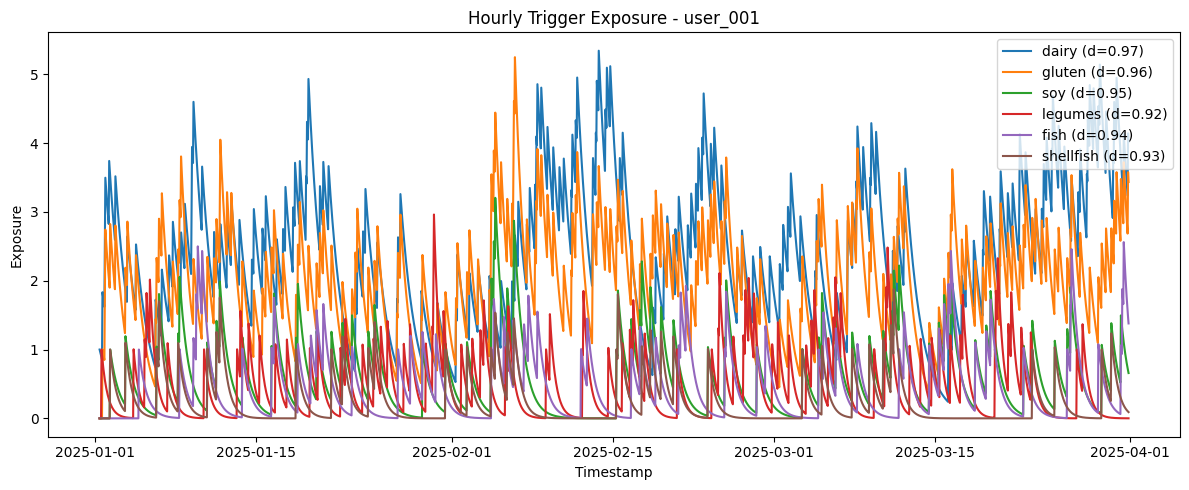

In [23]:
@dataclass
class Step2Config:
    default_decay_rate_per_hour: float = 0.97
    trigger_decay_rate_per_hour: Dict[str, float] = None
    intensity_per_meal_tag: float = 1.0
    use_logged_meals_only: bool = False
    plot_user_id: str = "user_001"

    def __post_init__(self):
        if self.trigger_decay_rate_per_hour is None:
            self.trigger_decay_rate_per_hour = {
                "gluten": 0.96,
                "dairy": 0.97,
                "soy": 0.95,
                "shellfish": 0.93,
                "fish": 0.94,
                "legumes": 0.92,
                "peanuts": 0.91,
                "egg": 0.94,
            }


def build_hourly_trigger_events(
    meals_df: pd.DataFrame,
    intensity_per_meal_tag: float,
    use_logged_meals_only: bool,
) -> pd.DataFrame:
    source = meals_df.copy()
    if use_logged_meals_only:
        source = source[source["logged"]].copy()

    events = source[["user_id", "timestamp", "tags"]].explode("tags")
    events = events.rename(columns={"tags": "trigger"}).dropna(subset=["trigger"])
    events = events[events["trigger"].astype(str).str.len() > 0].copy()
    events["hour"] = events["timestamp"].dt.floor("h")

    hourly_events = (
        events.groupby(["user_id", "hour", "trigger"]).size().rename("meal_count").reset_index()
    )
    hourly_events["trigger_intensity"] = (
        hourly_events["meal_count"] * float(intensity_per_meal_tag)
    )
    return hourly_events


def compute_hourly_exposure(
    meals_df: pd.DataFrame,
    cfg: Step2Config,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    hourly_events = build_hourly_trigger_events(
        meals_df=meals_df,
        intensity_per_meal_tag=cfg.intensity_per_meal_tag,
        use_logged_meals_only=cfg.use_logged_meals_only,
    )

    if hourly_events.empty:
        empty = pd.DataFrame(
            columns=["user_id", "timestamp", "trigger", "exposure", "decay_rate_per_hour"]
        )
        return empty, hourly_events

    all_rows = []

    for user_id in sorted(hourly_events["user_id"].unique().tolist()):
        user_meals = meals_df[meals_df["user_id"] == user_id]
        user_events = hourly_events[hourly_events["user_id"] == user_id]

        start_hour = user_meals["timestamp"].min().floor("h")
        end_hour = user_meals["timestamp"].max().ceil("h")
        timeline = pd.date_range(start=start_hour, end=end_hour, freq="h")

        triggers = sorted(user_events["trigger"].unique().tolist())
        decay_by_trigger = {
            trig: float(cfg.trigger_decay_rate_per_hour.get(trig, cfg.default_decay_rate_per_hour))
            for trig in triggers
        }

        event_map = {
            (row.hour, row.trigger): row.trigger_intensity
            for row in user_events.itertuples(index=False)
        }

        prev = pd.Series(0.0, index=triggers)
        for ts in timeline:
            for trig in triggers:
                prev[trig] = prev[trig] * decay_by_trigger[trig] + event_map.get((ts, trig), 0.0)
                all_rows.append(
                    {
                        "user_id": user_id,
                        "timestamp": ts,
                        "trigger": trig,
                        "exposure": float(prev[trig]),
                        "decay_rate_per_hour": decay_by_trigger[trig],
                    }
                )

    exposure_long = pd.DataFrame(all_rows).sort_values(
        ["user_id", "timestamp", "trigger"]
    ).reset_index(drop=True)

    return exposure_long, hourly_events


run_cfg = globals().get("RUN_CONFIG", {})

step2_cfg = Step2Config(
    default_decay_rate_per_hour=float(run_cfg.get("default_decay_rate_per_hour", 0.97)),
    trigger_decay_rate_per_hour=run_cfg.get("trigger_decay_rate_per_hour", {
        "gluten": 0.96,
        "dairy": 0.97,
        "soy": 0.95,
        "shellfish": 0.93,
        "fish": 0.94,
        "legumes": 0.92,
        "peanuts": 0.91,
        "egg": 0.94,
    }),
    intensity_per_meal_tag=float(run_cfg.get("exposure_intensity_per_meal_tag", 1.0)),
    use_logged_meals_only=bool(run_cfg.get("use_logged_meals_for_exposure", False)),
    plot_user_id=str(run_cfg.get("plot_user_id", "user_001")),
)

exposure_df, trigger_events_df = compute_hourly_exposure(meals_all_df, step2_cfg)

plot_user_id = (
    step2_cfg.plot_user_id
    if step2_cfg.plot_user_id in meals_all_df["user_id"].unique()
    else sorted(meals_all_df["user_id"].unique().tolist())[0]
)
plot_exposure_df = exposure_df[exposure_df["user_id"] == plot_user_id].copy()

print("Step 2 summary")
print(f"Users with exposure modeled: {exposure_df['user_id'].nunique() if len(exposure_df) else 0}")
print(f"Rows in hourly exposure table: {len(exposure_df)}")
print(f"Unique triggers: {exposure_df['trigger'].nunique() if len(exposure_df) else 0}")
print(f"Default decay rate per hour: {step2_cfg.default_decay_rate_per_hour}")
print(f"Using logged meals only: {step2_cfg.use_logged_meals_only}")
print(f"Intensity per meal-tag event: {step2_cfg.intensity_per_meal_tag}")
print(f"Plot user: {plot_user_id}")
if not exposure_df.empty:
    display(
        exposure_df[["trigger", "decay_rate_per_hour"]]
        .drop_duplicates()
        .sort_values("trigger")
        .reset_index(drop=True)
    )

display(trigger_events_df.head(10))
display(exposure_df.head(10))

# Plot sanity check for top triggers by peak exposure for one user.
import matplotlib.pyplot as plt

if not plot_exposure_df.empty:
    top_triggers = (
        plot_exposure_df.groupby("trigger")["exposure"].max().sort_values(ascending=False).head(6).index.tolist()
    )
    plot_df = plot_exposure_df[plot_exposure_df["trigger"].isin(top_triggers)]

    plt.figure(figsize=(12, 5))
    for trig in top_triggers:
        subset = plot_df[plot_df["trigger"] == trig]
        decay = step2_cfg.trigger_decay_rate_per_hour.get(trig, step2_cfg.default_decay_rate_per_hour)
        plt.plot(subset["timestamp"], subset["exposure"], label=f"{trig} (d={decay})")

    plt.title(f"Hourly Trigger Exposure - {plot_user_id}")
    plt.xlabel("Timestamp")
    plt.ylabel("Exposure")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [6]:
# Optional: export Step 2 outputs for later steps.
output_dir = Path(".")
exposure_df.to_csv(output_dir / "step2_exposure_hourly.csv", index=False)
trigger_events_df.to_csv(output_dir / "step2_trigger_events_hourly.csv", index=False)

print("Saved:")
print("- step2_exposure_hourly.csv")
print("- step2_trigger_events_hourly.csv")

Saved:
- step2_exposure_hourly.csv
- step2_trigger_events_hourly.csv


## Step 3: Symptom generation

Generate symptom events from exposure threshold crossings:
- assign each user an archetype profile
- when exposure crosses threshold, sample lag hours and create a symptom event
- scale severity based on how far exposure is above threshold
- apply symptom logging dropout (~30%)

Export `symptom_log.json` using logged symptom events only.

In [24]:
@dataclass
class Step3Config:
    seed: int = 123
    symptom_dropout_rate: float = 0.30
    cooldown_hours: int = 6
    noise_daily_prob_healthy: float = 0.06


ARCHETYPES = [
    {
        "name": "gluten_sensitive",
        "triggers": ["gluten"],
        "threshold": 0.9,
        "lag_hours": (12, 36),
        "symptoms": ["bloating", "cramping"],
        "severity_range": (4, 9),
    },
    {
        "name": "dairy_sensitive",
        "triggers": ["dairy"],
        "threshold": 0.85,
        "lag_hours": (6, 24),
        "symptoms": ["bloating", "gas"],
        "severity_range": (3, 8),
    },
    {
        "name": "legume_sensitive",
        "triggers": ["legumes"],
        "threshold": 0.8,
        "lag_hours": (4, 12),
        "symptoms": ["gas", "bloating"],
        "severity_range": (3, 7),
    },
    {
        "name": "healthy",
        "triggers": [],
        "threshold": None,
        "lag_hours": None,
        "symptoms": [],
        "severity_range": (1, 3),
    },
]


def assign_user_archetypes(user_ids: List[str], rng: np.random.Generator) -> pd.DataFrame:
    archetype_names = [a["name"] for a in ARCHETYPES]
    probs = np.array([0.32, 0.30, 0.20, 0.18], dtype=float)
    probs = probs / probs.sum()

    assigned = rng.choice(archetype_names, size=len(user_ids), p=probs)
    profile_df = pd.DataFrame({"user_id": user_ids, "archetype": assigned})
    return profile_df


def build_archetype_lookup() -> Dict[str, Dict]:
    return {a["name"]: a for a in ARCHETYPES}


def scale_severity(exposure_value: float, threshold: float, severity_range: tuple, rng: np.random.Generator) -> int:
    low, high = severity_range
    if threshold is None or threshold <= 0:
        return int(rng.integers(low, high + 1))

    over = max(exposure_value - threshold, 0.0)
    ratio = min(over / (threshold * 1.5), 1.0)
    raw = low + ratio * (high - low) + float(rng.normal(0.0, 0.4))
    return int(np.clip(np.rint(raw), low, high))


def generate_symptom_events(exposure_df: pd.DataFrame, cfg: Step3Config) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(cfg.seed)
    user_ids = sorted(exposure_df["user_id"].unique().tolist())

    user_profiles = assign_user_archetypes(user_ids, rng)
    archetype_lookup = build_archetype_lookup()

    symptom_records = []

    for profile in user_profiles.itertuples(index=False):
        user_id = profile.user_id
        archetype = archetype_lookup[profile.archetype]

        user_exposure = exposure_df[exposure_df["user_id"] == user_id].copy()
        user_exposure = user_exposure.sort_values(["trigger", "timestamp"]).reset_index(drop=True)

        if archetype["name"] == "healthy":
            daily_index = pd.date_range(
                user_exposure["timestamp"].min().floor("D"),
                user_exposure["timestamp"].max().floor("D"),
                freq="D",
            )
            for day in daily_index:
                if rng.random() < cfg.noise_daily_prob_healthy:
                    ts = day + pd.Timedelta(hours=int(rng.integers(8, 22)), minutes=int(rng.integers(0, 60)))
                    symptom_records.append(
                        {
                            "user_id": user_id,
                            "timestamp": ts,
                            "symptom": "mild_discomfort",
                            "severity": int(rng.integers(1, 4)),
                            "archetype": archetype["name"],
                            "trigger": None,
                            "logged": bool(rng.random() > cfg.symptom_dropout_rate),
                        }
                    )
            continue

        triggers = archetype["triggers"]
        threshold = archetype["threshold"]
        lag_low, lag_high = archetype["lag_hours"]
        sev_range = archetype["severity_range"]

        filtered = user_exposure[user_exposure["trigger"].isin(triggers)].copy()
        filtered["prev_exposure"] = filtered.groupby("trigger")["exposure"].shift(1).fillna(0.0)

        crossing = filtered[
            (filtered["prev_exposure"] < threshold) & (filtered["exposure"] >= threshold)
        ].copy()

        last_event_time = None
        for row in crossing.itertuples(index=False):
            base_time = row.timestamp
            if last_event_time is not None and base_time < last_event_time + pd.Timedelta(hours=cfg.cooldown_hours):
                continue

            lag_hours = int(rng.integers(lag_low, lag_high + 1))
            symptom_time = base_time + pd.Timedelta(hours=lag_hours)
            symptom_name = str(rng.choice(archetype["symptoms"]))
            severity = scale_severity(
                exposure_value=float(row.exposure),
                threshold=float(threshold),
                severity_range=sev_range,
                rng=rng,
            )

            symptom_records.append(
                {
                    "user_id": user_id,
                    "timestamp": symptom_time,
                    "symptom": symptom_name,
                    "severity": severity,
                    "archetype": archetype["name"],
                    "trigger": row.trigger,
                    "logged": bool(rng.random() > cfg.symptom_dropout_rate),
                }
            )
            last_event_time = base_time

    symptom_all_df = pd.DataFrame(symptom_records)
    if symptom_all_df.empty:
        symptom_all_df = pd.DataFrame(
            columns=["user_id", "timestamp", "symptom", "severity", "archetype", "trigger", "logged"]
        )

    symptom_all_df = symptom_all_df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
    symptom_logged_df = symptom_all_df[symptom_all_df["logged"]].reset_index(drop=True)

    return symptom_all_df, symptom_logged_df, user_profiles


run_cfg = globals().get("RUN_CONFIG", {})

step3_cfg = Step3Config(
    seed=int(run_cfg.get("seed_step3", 123)),
    symptom_dropout_rate=float(run_cfg.get("symptom_dropout_rate", 0.30)),
    cooldown_hours=int(run_cfg.get("symptom_cooldown_hours", 6)),
    noise_daily_prob_healthy=float(run_cfg.get("healthy_noise_daily_prob", 0.06)),
)

symptom_all_df, symptom_logged_df, symptom_user_profiles_df = generate_symptom_events(exposure_df, step3_cfg)

print("Step 3 summary")
print(f"Users with archetype assignments: {symptom_user_profiles_df['user_id'].nunique()}")
print(f"Total symptom events (pre-dropout): {len(symptom_all_df)}")
print(f"Logged symptom events: {len(symptom_logged_df)}")
if len(symptom_all_df) > 0:
    print(f"Symptom logging rate: {symptom_logged_df.shape[0] / symptom_all_df.shape[0]:.2%}")
print(f"Healthy daily noise probability: {step3_cfg.noise_daily_prob_healthy}")

display(symptom_user_profiles_df['archetype'].value_counts().rename_axis('archetype').reset_index(name='users'))
display(symptom_logged_df.head(10))

Step 3 summary
Users with archetype assignments: 40
Total symptom events (pre-dropout): 892
Logged symptom events: 604
Symptom logging rate: 67.71%
Healthy daily noise probability: 0.06


,archetype,users
0,gluten_sensitive,15
1,legume_sensitive,10
2,healthy,9
3,dairy_sensitive,6


,user_id,timestamp,symptom,severity,archetype,trigger,logged
0,user_001,2025-01-04 17:00:00,bloating,3,legume_sensitive,legumes,True
1,user_001,2025-01-05 14:00:00,gas,4,legume_sensitive,legumes,True
2,user_001,2025-01-10 18:00:00,gas,4,legume_sensitive,legumes,True
3,user_001,2025-01-13 14:00:00,gas,3,legume_sensitive,legumes,True
4,user_001,2025-01-13 19:00:00,gas,6,legume_sensitive,legumes,True
5,user_001,2025-01-14 17:00:00,bloating,5,legume_sensitive,legumes,True
6,user_001,2025-01-15 19:00:00,gas,4,legume_sensitive,legumes,True
7,user_001,2025-01-16 23:00:00,bloating,4,legume_sensitive,legumes,True
8,user_001,2025-01-18 03:00:00,gas,4,legume_sensitive,legumes,True
9,user_001,2025-01-20 00:00:00,bloating,4,legume_sensitive,legumes,True


In [12]:
# Optional: export Step 3 outputs.
output_dir = Path(".")
symptom_all_df.to_csv(output_dir / "step3_symptoms_all.csv", index=False)
symptom_logged_df.to_csv(output_dir / "step3_symptoms_logged.csv", index=False)
symptom_user_profiles_df.to_csv(output_dir / "step3_user_archetypes.csv", index=False)

symptom_log_records = symptom_logged_df[
    ["user_id", "timestamp", "symptom", "severity"]
].copy()
symptom_log_records["timestamp"] = pd.to_datetime(symptom_log_records["timestamp"]).dt.strftime("%Y-%m-%dT%H:%M:%S")

with (output_dir / "symptom_log.json").open("w", encoding="utf-8") as f:
    json.dump(symptom_log_records.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

user_archetypes = dict(
    zip(
        symptom_user_profiles_df["user_id"].astype(str),
        symptom_user_profiles_df["archetype"].astype(str),
    )
)
archetype_definitions = {a["name"]: a for a in ARCHETYPES}
ground_truth_payload = {
    "user_archetypes": user_archetypes,
    "archetype_definitions": archetype_definitions,
}

with (output_dir / "ground_truth.json").open("w", encoding="utf-8") as f:
    json.dump(ground_truth_payload, f, ensure_ascii=False, indent=2)

print("Saved:")
print("- step3_symptoms_all.csv")
print("- step3_symptoms_logged.csv")
print("- step3_user_archetypes.csv")
print("- symptom_log.json")
print("- ground_truth.json")
print(f"symptom_log.json records: {len(symptom_log_records)}")
print(f"ground_truth users: {len(user_archetypes)}")

Saved:
- step3_symptoms_all.csv
- step3_symptoms_logged.csv
- step3_user_archetypes.csv
- symptom_log.json
- ground_truth.json
symptom_log.json records: 604
ground_truth users: 40


## Step 5.1: Visual validation for user_001

These charts are designed to be legible and diagnostic for one user:
- Daily logged meal volume by meal type
- Hourly trigger exposure (top triggers)
- Symptom severity timeline
- Daily exposure burden vs daily symptom severity

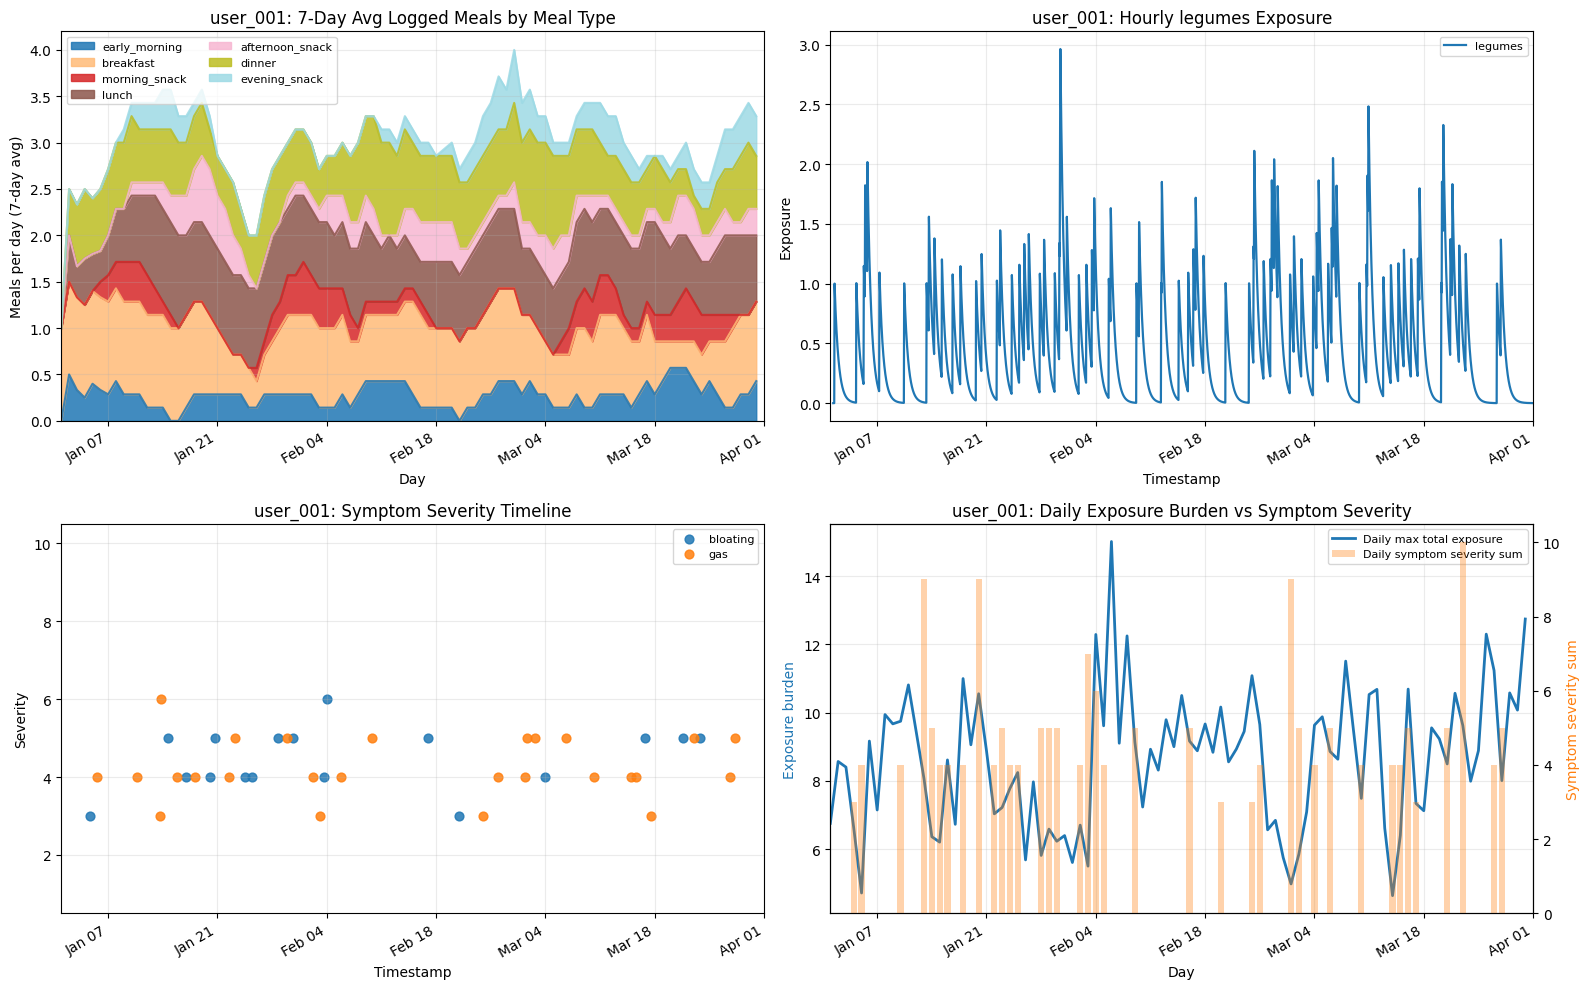

Visualized user: user_001
User archetype: legume_sensitive
Tracked exposure tag (Graph 2): legumes
Shared x-range: 2025-01-01 00:00:00 to 2025-04-01 00:00:00
Logged meals: 271
Logged symptoms: 43


In [25]:
run_cfg = globals().get("RUN_CONFIG", {})
user_focus = str(run_cfg.get("plot_user_id", "user_001"))

u_meals = meals_logged_df[meals_logged_df["user_id"] == user_focus].copy()
u_exposure = exposure_df[exposure_df["user_id"] == user_focus].copy()
u_symptoms = symptom_logged_df[symptom_logged_df["user_id"] == user_focus].copy()

u_meals["timestamp"] = pd.to_datetime(u_meals["timestamp"])
u_exposure["timestamp"] = pd.to_datetime(u_exposure["timestamp"])
u_symptoms["timestamp"] = pd.to_datetime(u_symptoms["timestamp"])

if u_meals.empty or u_exposure.empty:
    print(f"No data available for {user_focus}.")
else:
    import matplotlib.dates as mdates

    meal_daily = (
        u_meals.assign(day=u_meals["timestamp"].dt.floor("D"))
        .groupby(["day", "meal_type"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    # Force chronological stacking order from earliest meal to latest meal.
    meal_order = [
        "early_morning",
        "breakfast",
        "morning_snack",
        "lunch",
        "afternoon_snack",
        "dinner",
        "evening_snack",
    ]
    meal_daily = meal_daily.reindex(columns=meal_order, fill_value=0)
    meal_daily_7d = meal_daily.rolling(7, min_periods=1).mean()

    user_archetype = user_archetypes.get(user_focus, "healthy")
    user_def = archetype_definitions.get(user_archetype, {})
    user_triggers = user_def.get("triggers", [])
    susceptible_tag = user_triggers[0] if len(user_triggers) > 0 else "gluten"

    exp_plot = u_exposure[u_exposure["trigger"] == susceptible_tag].copy()

    daily_exposure_burden = (
        u_exposure.groupby("timestamp", as_index=False)["exposure"].sum()
        .assign(day=lambda df: df["timestamp"].dt.floor("D"))
        .groupby("day")["exposure"]
        .max()
    )

    daily_symptom_severity = (
        u_symptoms.assign(day=u_symptoms["timestamp"].dt.floor("D"))
        .groupby("day")["severity"]
        .sum()
        .reindex(daily_exposure_burden.index, fill_value=0)
    )

    # Shared timestamp bounds for all four charts.
    min_ts = min(u_meals["timestamp"].min(), u_exposure["timestamp"].min())
    max_ts = max(u_meals["timestamp"].max(), u_exposure["timestamp"].max())
    min_day = min_ts.floor("D")
    max_day = max_ts.ceil("D")

    plt.style.use("default")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1) Smoother meal pattern chart for legibility.
    meal_daily_7d.plot.area(ax=axes[0, 0], stacked=True, alpha=0.85, colormap="tab20")
    axes[0, 0].set_title(f"{user_focus}: 7-Day Avg Logged Meals by Meal Type")
    axes[0, 0].set_xlabel("Day")
    axes[0, 0].set_ylabel("Meals per day (7-day avg)")
    axes[0, 0].legend(loc="upper left", fontsize=8, ncol=2, frameon=True)

    # 2) Hourly exposure line for the susceptible tag (or gluten for healthy users).
    if not exp_plot.empty:
        axes[0, 1].plot(exp_plot["timestamp"], exp_plot["exposure"], label=susceptible_tag, linewidth=1.6)
    axes[0, 1].set_title(f"{user_focus}: Hourly {susceptible_tag} Exposure")
    axes[0, 1].set_xlabel("Timestamp")
    axes[0, 1].set_ylabel("Exposure")
    axes[0, 1].legend(loc="upper right", fontsize=8, frameon=True)

    # 3) Symptom severity timeline.
    if not u_symptoms.empty:
        symptom_types = sorted(u_symptoms["symptom"].unique().tolist())
        cmap = plt.get_cmap("tab10")
        for idx, symptom_name in enumerate(symptom_types):
            s = u_symptoms[u_symptoms["symptom"] == symptom_name]
            axes[1, 0].scatter(
                s["timestamp"],
                s["severity"],
                label=symptom_name,
                s=40,
                alpha=0.85,
                color=cmap(idx % 10),
            )
        axes[1, 0].set_ylim(0.5, 10.5)
        axes[1, 0].set_title(f"{user_focus}: Symptom Severity Timeline")
        axes[1, 0].set_xlabel("Timestamp")
        axes[1, 0].set_ylabel("Severity")
        axes[1, 0].legend(loc="upper right", fontsize=8, frameon=True)
    else:
        axes[1, 0].text(0.5, 0.5, "No logged symptoms", ha="center", va="center")
        axes[1, 0].set_title(f"{user_focus}: Symptom Severity Timeline")
        axes[1, 0].set_axis_off()

    # 4) Daily exposure burden vs daily symptom severity.
    ax_left = axes[1, 1]
    ax_right = ax_left.twinx()

    ax_left.plot(
        daily_exposure_burden.index,
        daily_exposure_burden.values,
        color="#1f77b4",
        linewidth=2,
        label="Daily max total exposure",
    )
    ax_right.bar(
        daily_symptom_severity.index,
        daily_symptom_severity.values,
        color="#ff7f0e",
        alpha=0.35,
        label="Daily symptom severity sum",
    )

    ax_left.set_title(f"{user_focus}: Daily Exposure Burden vs Symptom Severity")
    ax_left.set_xlabel("Day")
    ax_left.set_ylabel("Exposure burden", color="#1f77b4")
    ax_right.set_ylabel("Symptom severity sum", color="#ff7f0e")

    left_handles, left_labels = ax_left.get_legend_handles_labels()
    right_handles, right_labels = ax_right.get_legend_handles_labels()
    ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc="upper right", fontsize=8, frameon=True)

    # Shared date axis formatting for legibility and synchronized range.
    date_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]
    for ax in date_axes:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        ax.set_xlim(min_day, max_day)
        for label in ax.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment("right")
        ax.grid(alpha=0.25)

    # Keep the twin axis perfectly aligned with its primary axis.
    ax_right.set_xlim(min_day, max_day)

    plt.tight_layout()
    plt.show()

    print(f"Visualized user: {user_focus}")
    print(f"User archetype: {user_archetype}")
    print(f"Tracked exposure tag (Graph 2): {susceptible_tag}")
    print(f"Shared x-range: {min_day} to {max_day}")
    print(f"Logged meals: {len(u_meals)}")
    print(f"Logged symptoms: {len(u_symptoms)}")

## Step 5.2: Advanced diagnostics for user_001

Additional visual checks to validate temporal plausibility:
- Lag distribution: trigger threshold crossing to logged symptom onset
- Event-aligned average exposure around symptom onset
- Symptom severity vs recent exposure (24h lookback)

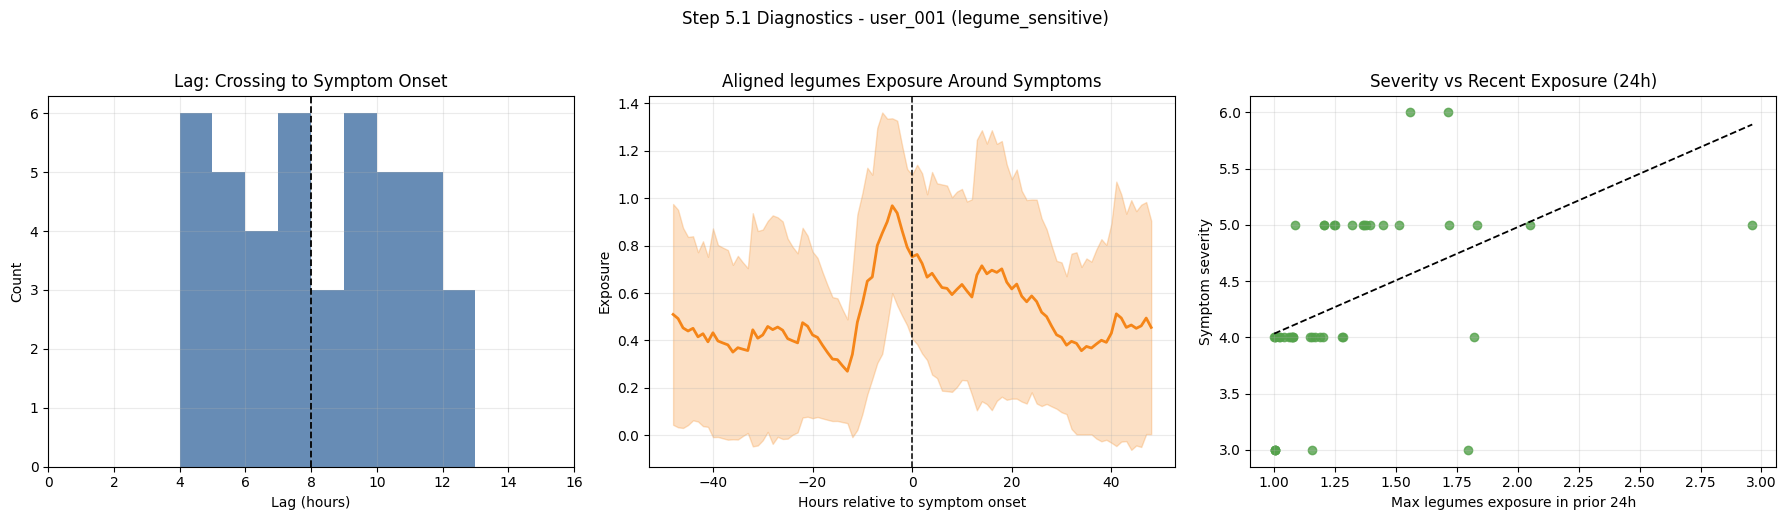

Diagnostics user: user_001
User archetype: legume_sensitive
Susceptible tag analyzed: legumes
Crossing threshold used: 0.8
Lag pairs counted: 43
Severity points counted: 43


In [26]:
# Step 5.1 diagnostics for the same focus user.
# Uses existing variables from prior steps: user_archetypes, archetype_definitions,
# meals_logged_df, exposure_df, symptom_logged_df.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_cfg = globals().get("RUN_CONFIG", {})
user_focus = str(run_cfg.get("plot_user_id", "user_001"))
lookback_hours_for_severity = int(run_cfg.get("diag_severity_lookback_hours", 24))
max_lag_hours = int(run_cfg.get("diag_max_lag_match_hours", 72))
window_hours = int(run_cfg.get("diag_window_hours", 48))
lag_axis_min_hours = float(run_cfg.get("diag_lag_axis_min_hours", 0))
lag_axis_max_hours = float(run_cfg.get("diag_lag_axis_max_hours", 16))

u_exp = exposure_df[exposure_df["user_id"] == user_focus].copy()
u_sym = symptom_logged_df[symptom_logged_df["user_id"] == user_focus].copy()

if u_exp.empty:
    print(f"No exposure data available for {user_focus}.")
else:
    u_exp["timestamp"] = pd.to_datetime(u_exp["timestamp"])
    u_sym["timestamp"] = pd.to_datetime(u_sym["timestamp"])

    user_archetype = user_archetypes.get(user_focus, "healthy")
    user_def = archetype_definitions.get(user_archetype, {})
    user_triggers = user_def.get("triggers", [])
    susceptible_tag = user_triggers[0] if len(user_triggers) > 0 else "gluten"
    threshold = user_def.get("threshold", None)

    tag_exp = (
        u_exp[u_exp["trigger"] == susceptible_tag]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Lag histogram: threshold-crossing to symptom onset.
    lag_hours = []
    crossing_times = []
    if not tag_exp.empty and threshold is not None:
        tag_exp["prev_exposure"] = tag_exp["exposure"].shift(1).fillna(0.0)
        crossings = tag_exp[
            (tag_exp["prev_exposure"] < float(threshold))
            & (tag_exp["exposure"] >= float(threshold))
        ]
        crossing_times = crossings["timestamp"].tolist()

    if len(crossing_times) > 0 and not u_sym.empty:
        crossing_index = pd.Index(crossing_times)
        for ts in u_sym["timestamp"].sort_values().tolist():
            prior_crossings = crossing_index[crossing_index <= ts]
            if len(prior_crossings) == 0:
                continue
            lag = (ts - prior_crossings.max()) / pd.Timedelta(hours=1)
            if 0 <= lag <= max_lag_hours:
                lag_hours.append(float(lag))

    if len(lag_hours) > 0:
        bins = np.arange(lag_axis_min_hours, lag_axis_max_hours + 1, 1.0)
        axes[0].hist(lag_hours, bins=bins, range=(lag_axis_min_hours, lag_axis_max_hours), color="#4C78A8", alpha=0.85)
        axes[0].axvline(np.median(lag_hours), color="black", linestyle="--", linewidth=1.3)
        axes[0].set_xlim(lag_axis_min_hours, lag_axis_max_hours)
        axes[0].set_title("Lag: Crossing to Symptom Onset")
        axes[0].set_xlabel("Lag (hours)")
        axes[0].set_ylabel("Count")
    else:
        axes[0].text(0.5, 0.5, "Insufficient crossing/symptom pairs", ha="center", va="center")
        axes[0].set_title("Lag: Crossing to Symptom Onset")
        axes[0].set_axis_off()

    # 2) Event-aligned exposure around symptom onset (mean +/- 1 SD).
    rel_hours = np.arange(-window_hours, window_hours + 1)
    aligned_curves = []

    if not tag_exp.empty and not u_sym.empty:
        exp_series = tag_exp.set_index("timestamp")["exposure"].sort_index()
        for ts in u_sym["timestamp"].tolist():
            idx = ts + pd.to_timedelta(rel_hours, unit="h")
            vals = exp_series.reindex(idx)
            if vals.notna().sum() > 0:
                aligned_curves.append(vals.values.astype(float))

    if len(aligned_curves) > 0:
        arr = np.vstack(aligned_curves)
        mean_curve = np.nanmean(arr, axis=0)
        std_curve = np.nanstd(arr, axis=0)

        axes[1].plot(rel_hours, mean_curve, color="#F58518", linewidth=2)
        axes[1].fill_between(
            rel_hours,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color="#F58518",
            alpha=0.25,
        )
        axes[1].axvline(0, color="black", linestyle="--", linewidth=1.1)
        axes[1].set_title(f"Aligned {susceptible_tag} Exposure Around Symptoms")
        axes[1].set_xlabel("Hours relative to symptom onset")
        axes[1].set_ylabel("Exposure")
    else:
        axes[1].text(0.5, 0.5, "Insufficient exposure/symptom overlap", ha="center", va="center")
        axes[1].set_title("Event-Aligned Exposure")
        axes[1].set_axis_off()

    # 3) Symptom severity vs recent exposure.
    x_recent_exp = []
    y_severity = []

    if not tag_exp.empty and not u_sym.empty:
        exp_series = tag_exp.set_index("timestamp")["exposure"].sort_index()
        for row in u_sym[["timestamp", "severity"]].itertuples(index=False):
            t0 = row.timestamp - pd.Timedelta(hours=lookback_hours_for_severity)
            recent = exp_series.loc[(exp_series.index > t0) & (exp_series.index <= row.timestamp)]
            if len(recent) > 0:
                x_recent_exp.append(float(recent.max()))
                y_severity.append(float(row.severity))

    if len(x_recent_exp) > 0:
        axes[2].scatter(x_recent_exp, y_severity, alpha=0.8, color="#54A24B")
        if len(x_recent_exp) >= 2:
            m, b = np.polyfit(np.array(x_recent_exp), np.array(y_severity), 1)
            xx = np.linspace(min(x_recent_exp), max(x_recent_exp), 100)
            axes[2].plot(xx, m * xx + b, color="black", linewidth=1.3, linestyle="--")
        axes[2].set_title(f"Severity vs Recent Exposure ({lookback_hours_for_severity}h)")
        axes[2].set_xlabel(f"Max {susceptible_tag} exposure in prior {lookback_hours_for_severity}h")
        axes[2].set_ylabel("Symptom severity")
    else:
        axes[2].text(0.5, 0.5, "Insufficient data for severity linkage", ha="center", va="center")
        axes[2].set_title("Severity vs Recent Exposure")
        axes[2].set_axis_off()

    for ax in axes:
        ax.grid(alpha=0.25)

    plt.suptitle(f"Step 5.1 Diagnostics - {user_focus} ({user_archetype})", y=1.03)
    plt.tight_layout()
    plt.show()

    print(f"Diagnostics user: {user_focus}")
    print(f"User archetype: {user_archetype}")
    print(f"Susceptible tag analyzed: {susceptible_tag}")
    print(f"Crossing threshold used: {threshold}")
    print(f"Lag pairs counted: {len(lag_hours)}")
    print(f"Severity points counted: {len(x_recent_exp)}")